GHZ probabilities: {np.str_('000'): np.float64(0.5), np.str_('111'): np.float64(0.5)}
W probabilities: {np.str_('001'): np.float64(0.333), np.str_('010'): np.float64(0.333), np.str_('100'): np.float64(0.333)}


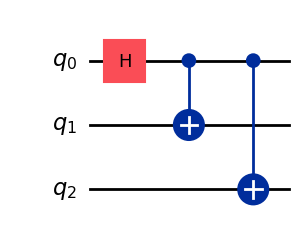

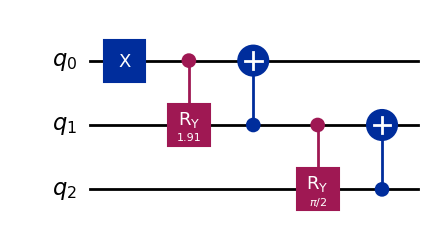


State Purity(0,1)   Concurrence(0,1)   Entangled?
GHZ   0.500         0.000              No (separable)
W     0.556         0.667              Yes

Conditional collapse of qubits (0,1) after measuring qubit 2:
 GHZ:
   qubit2=0: probability 0.500, remaining pair amplitudes [00,01,10,11] = [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
   qubit2=1: probability 0.500, remaining pair amplitudes [00,01,10,11] = [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 W:
   qubit2=0: probability 0.667, remaining pair amplitudes [00,01,10,11] = [0.   +0.j 0.707+0.j 0.707+0.j 0.   +0.j]
   qubit2=1: probability 0.333, remaining pair amplitudes [00,01,10,11] = [1.+0.j 0.+0.j 0.+0.j 0.+0.j]


In [2]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, concurrence, purity
from qiskit_aer import AerSimulator
def w_state(n):
    """Standard cascade construction of the n-qubit W state."""
    qc = QuantumCircuit(n)
    qc.x(0)
    for i in range(n - 1):
        theta = np.arccos(np.sqrt(1 / (n - i)))
        qc.cry(2 * theta, i, i + 1)  # spread the excitation onto qubit i+1
        qc.cx(i + 1, i)  # move it off qubit i if it was transferred
    return qc

ghz = QuantumCircuit(3)
ghz.h(0); ghz.cx(0, 1); ghz.cx(0, 2)  # (|000> + |111>) / sqrt(2)

w = w_state(3)  # (|001> + |010> + |100>) / sqrt(3)

for name, qc in [("GHZ", ghz), ("W", w)]:
    sv = Statevector(qc)
    print(f"{name} probabilities:", {k: round(v, 3) for k, v in sv.probabilities_dict().items()})

display(ghz.draw(output='mpl', style='iqp'))
display(w.draw(output='mpl', style='iqp'))

# Trace out qubit 2 and quantify entanglement left between qubits 0 and 1
print(f"\n{'State':<6}{'Purity(0,1)':<14}{'Concurrence(0,1)':<19}{'Entangled?'}")
for name, qc in [("GHZ", ghz), ("W", w)]:
    reduced = partial_trace(DensityMatrix(Statevector(qc)), [2])
    p, c = purity(reduced).real, concurrence(reduced)
    print(f"{name:<6}{p:<14.3f}{c:<19.3f}{'Yes' if c > 1e-6 else 'No (separable)'}")

# What happens to qubits (0,1) conditioned on the actual outcome of measuring qubit 2?
print("\nConditional collapse of qubits (0,1) after measuring qubit 2:")
for name, qc in [("GHZ", ghz), ("W", w)]:
    amp = Statevector(qc).data
    print(f" {name}:")
    for outcome in ["0", "1"]:
        idx = [i for i in range(8) if format(i, '03b')[0] == outcome]
        sub = amp[idx]
        prob = np.sum(np.abs(sub) ** 2)
        if prob < 1e-9:
            print(f"   qubit2={outcome}: probability {prob:.3f} (never happens)")
            continue
        sub = sub / np.sqrt(prob)
        print(f"   qubit2={outcome}: probability {prob:.3f}, remaining pair amplitudes "
              f"[00,01,10,11] = {np.round(sub, 3)}")